# Prelim analyses
This notebook is for generating some preliminary data/analyses for the NSF CRCNS grant that I'm working on with Christa and Sama.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Making sense of the Flywire FAFB data
There are multiple different dataframes with different numbers of rows. 

"names" appears to be all the bodies in the data. It has more rows (139,255) than "types", so I am guessing that it includes neurons that are cropped and/or not fully traced, and maybe some fragments and orphans. Flywire doesn't specify. 

"types" has fewer rows (137,677) than "names". I guess the missing neurons haven't been typed. It has 2 columns of cell type names which would be handy to consolidate. 

In [2]:
# I don't understand these names yet, but they are not the cell types
names = pd.read_csv("/Users/ggutierr/Documents/FlyWireData/names.csv")
names

,root_id,name,group
0,720575940596125868,LO.LOP.561,LO.LOP
1,720575940597856265,ME.2982,ME
2,720575940597944841,ME.LO.7713,ME.LO
3,720575940598267657,ME.4244,ME
4,720575940599333574,ME.5182,ME
...,...,...,...
139250,720575940661335681,GNG.962,GNG
139251,720575940661336193,ME.LO.500,ME.LO
139252,720575940661337217,SCL.MB_ML.12,SCL.MB_ML
139253,720575940661338497,GNG.878,GNG


In [3]:
types = pd.read_csv("/Users/ggutierr/Documents/FlyWireData/consolidated_cell_types.csv")
#types.rename(columns={"root_id": "id"}, inplace=True)
types

,root_id,primary_type,additional_type(s)
0,720575940596125868,T5c,NaN
1,720575940597856265,Tm16,NaN
2,720575940597944841,Tm7,CB3851
3,720575940598267657,TmY15,NaN
4,720575940599333574,Tm1,NaN
...,...,...,...
137672,720575940661335681,CB0180,NaN
137673,720575940661336193,TmY3,NaN
137674,720575940661337217,KCab-p,NaN
137675,720575940661338497,CB0904,NaN


"classification" has the same number of rows as "names". \
Flow - Top hierarchical annotation describing signal flow of this neuron. \
Super Class - Broadest hierarchical annotation below “flow”.\
Class & Sub Class - Provides useful labels for small to medium-sized groups of neurons and sits between superclass and cell type.\
Side - Soma side of the neuron in fly's perspective. Note: corrected for the left/right inversion of the FAFB image data (see FAQ page for details).\
Nerve - Nerve through which the neuron is entering/exiting the nervous system.\
Hemilineage - Developmental (hemi-)lineage, can contain multiple cell types that are often morphologically similar.

In [4]:
classification = pd.read_csv("/Users/ggutierr/Documents/FlyWireData/classification.csv")
classification

,root_id,flow,super_class,class,sub_class,hemilineage,side,nerve
0,720575940596125868,intrinsic,optic,optic_lobe_intrinsic,t5_neuron,NaN,right,NaN
1,720575940597856265,intrinsic,optic,optic_lobe_intrinsic,transmedullary,NaN,right,NaN
2,720575940597944841,intrinsic,optic,optic_lobe_intrinsic,transmedullary,NaN,right,NaN
3,720575940598267657,intrinsic,optic,optic_lobe_intrinsic,transmedullary_y,NaN,right,NaN
4,720575940599333574,intrinsic,optic,optic_lobe_intrinsic,transmedullary,NaN,right,NaN
...,...,...,...,...,...,...,...,...
139250,720575940661335681,intrinsic,central,NaN,NaN,MX12__prim,left,NaN
139251,720575940661336193,intrinsic,optic,optic_lobe_intrinsic,transmedullary_y,NaN,left,NaN
139252,720575940661337217,intrinsic,central,Kenyon_Cell,NaN,MBp4,left,NaN
139253,720575940661338497,efferent,motor,NaN,NaN,putative_primary,right,PhN


"connections_princeton" are all the connections with at least 5 total synapses. The rows indicate weights by neuropil, so this df needs to be grouped by id pairs in order to get "simple_connections".

In [5]:
connections_princeton = pd.read_csv("/Users/ggutierr/Documents/FlyWireData/connections_princeton.csv")
connections_princeton

,pre_root_id,post_root_id,neuropil,syn_count,nt_type
0,720575940625363947,720575940623224444,ME_L,12,GABA
1,720575940630432382,720575940618518557,ME_L,67,ACH
2,720575940627314521,720575940626337738,ME_L,10,GABA
3,720575940620280405,720575940620204726,ME_L,15,ACH
4,720575940636942447,720575940613789411,LA_L,1,GLUT
...,...,...,...,...,...
5342441,720575940610739918,720575940617129885,PLP_L,5,ACH
5342442,720575940653332385,720575940623905719,CRE_R,2,ACH
5342443,720575940622485887,720575940631031803,ME_R,9,ACH
5342444,720575940620020534,720575940636489140,SMP_L,2,ACH


In [6]:
# group by id pairs to get simple connections, but keep nt_type of the most prevalent synapse group
simple_connections = connections_princeton.sort_values('syn_count', ascending=False)
simple_connections = simple_connections.groupby(['pre_root_id', 'post_root_id']).agg({'syn_count': 'sum', 'nt_type': 'first'}).reset_index()
simple_connections

,pre_root_id,post_root_id,syn_count,nt_type
0,720575940596125868,720575940605825666,6,ACH
1,720575940596125868,720575940608552405,6,ACH
2,720575940596125868,720575940609975854,5,ACH
3,720575940596125868,720575940613059993,9,ACH
4,720575940596125868,720575940613599129,6,ACH
...,...,...,...,...
3732455,720575940661339777,720575940622727152,37,ACH
3732456,720575940661339777,720575940625109995,5,ACH
3732457,720575940661339777,720575940627311491,40,ACH
3732458,720575940661339777,720575940628084873,19,ACH


## Auditory data
unique_neuron_ids.json is the list of root ids for the auditory neurons that Sama gave me. Train_dat.csv has info for the neurons with tunings. All but 2 of those are included in unique_neuron_ids and I don't know why those 2 are missing.

Flywire provides a label for auditory neurons in its classification table under the sub_class colum, but it only labels 272 neurons. All of those are JO-A and JO-B types.

In [7]:
import pandas as pd
import numpy as np
import json
#_auditory_neuron_conns = pd.read_csv("auditory_neuron_connections.csv.gz", compression='gzip')

#auditory_neuron_conns = _auditory_neuron_conns.rename(columns={"Unnamed: 0": "index_in_connections_table"})

with open("unique_neuron_ids.json", "r") as f:
    unique_auditory_ids = json.load(f)

len(unique_auditory_ids)

21942

In [8]:
# Some auditory neurons with selectivity labels provided by Ian from Sama's lab
train_dat = pd.read_csv("data/train_dat.csv")
train_dat

,Unnamed: 0,Flywire 2024 ID,Neuropils,preference,# imaged females,# responding females,prop females with auditory responses
0,0,720575940619783518,AVLP_pr01,sine,4,4,1.000000
1,1,720575940620062633,AVLP_pr01,sine,4,4,1.000000
2,2,720575940602914988,AVLP_pr01,sine,4,4,1.000000
3,3,720575940620195719,AVLP_pr01,sine,4,4,1.000000
4,4,720575940634508174,AVLP_pr01,sine,4,4,1.000000
...,...,...,...,...,...,...,...
398,398,720575940655398817,GNG_pr01,sine,17,4,0.235294
399,399,720575940630203589,GNG_pr01,sine,17,4,0.235294
400,400,720575940617641077,GNG_pr01,sine,17,4,0.235294
401,401,720575940612801022,GNG_pr01,sine,17,4,0.235294


In [9]:
# are all the ids in train_dat part of unique_auditory_ids?
all(train_dat['Flywire 2024 ID'].isin(unique_auditory_ids))

False

In [10]:
# are any of the ids in train_dat part of unique_auditory_ids?
any(train_dat['Flywire 2024 ID'].isin(unique_auditory_ids))

True

In [11]:
# how many ids in train_dat are part of unique_auditory_ids?
sum(train_dat['Flywire 2024 ID'].isin(unique_auditory_ids))

401

In [12]:
classification[classification['root_id'].isin(unique_auditory_ids)]

,root_id,flow,super_class,class,sub_class,hemilineage,side,nerve
23,720575940600433181,afferent,sensory,mechanosensory,auditory,NaN,left,AN
27,720575940600646173,afferent,sensory,mechanosensory,NaN,NaN,left,AN
48,720575940602120928,intrinsic,central,NaN,NaN,VLPa1_medial,left,NaN
49,720575940602132509,afferent,sensory,mechanosensory,NaN,NaN,left,AN
52,720575940602309600,afferent,ascending,AN,SA_DMT_DMetaN,NaN,right,CV
...,...,...,...,...,...,...,...,...
139243,720575940661321857,intrinsic,central,NaN,NaN,VPNp&v1_posterior,right,NaN
139246,720575940661325697,intrinsic,visual_projection,bilateral,NaN,NaN,left,NaN
139248,720575940661329281,intrinsic,central,NaN,NaN,VLPl&d1_lateral,left,NaN
139250,720575940661335681,intrinsic,central,NaN,NaN,MX12__prim,left,NaN


In [13]:
classification[classification['root_id'].isin(unique_auditory_ids)]['super_class'].value_counts()

super_class
central               12678
visual_projection      3001
sensory                2570
ascending              1980
descending             1207
visual_centrifugal      275
optic                   117
motor                   100
endocrine                14
Name: count, dtype: int64

In [14]:
classification[classification['root_id'].isin(unique_auditory_ids)]['class'].value_counts()

class
mechanosensory          2146
AN                      1980
gustatory                339
ALPN                     112
unknown_sensory           82
optic_lobe_intrinsic      82
bilateral                 55
CX                        55
LHCENT                    26
ALIN                      24
ALON                      13
ALLN                      11
ocellar                   10
optic_lobes                7
pars_lateralis             6
LHLN                       5
MBON                       4
DAN                        4
pars_intercerebralis       2
MBIN                       1
olfactory                  1
Name: count, dtype: int64

In [15]:
classification[classification['root_id'].isin(unique_auditory_ids)]['sub_class'].value_counts()

sub_class
eye_bristle       922
AN_GNG            592
head_bristle      300
auditory          272
AN_multi          271
                 ... 
AN_LH_AVLP          1
AN_AMMC_SAD         1
AN_FLA_VES          1
transmedullary      1
AN_GNG_AVLP         1
Name: count, Length: 71, dtype: int64

In [16]:
types[types['root_id'].isin(classification[classification['sub_class'] == 'auditory']['root_id'].tolist())]['primary_type'].value_counts()

primary_type
JO-B    299
JO-A     94
Name: count, dtype: int64

In [17]:
types[types['root_id'].isin(classification[classification['sub_class'] == 'auditory']['root_id'].tolist())]['additional_type(s)'].value_counts()

Series([], Name: count, dtype: int64)

# Mating cell types and effectors 
The main effectors that I will consider are the pMN1/DNp13 and pMN2/DNp37/vpoDN. These are both descending neurons. pMN1 is for ovipositor extension in the context of mating rejection. pMN2 is also for ovipositor extension in the context of oviposition and it is for vaginal plate opening in the context of receptivity. 

There are also some interneurons to throw into the mix of our investigations. The vpoEN, vpoIN, pC2l, and pC1 (especially d-e subtypes).

In [16]:
sexy_types = types[types['additional_type(s)'].str.contains('vpo|pC2l|pMN|pC1d|pC1e|DNp13|DNp37', case=False, na=False)|types['primary_type'].str.contains('vpo|pC2l|pMN|pC1d|pC1e|DNp13|DNp37',na=False)]
sexy_types

,root_id,primary_type,additional_type(s)
8938,720575940610359758,pC2la,NaN
8955,720575940610373326,CB2375,pC2la
9126,720575940610455781,CL313,pC2la
11115,720575940611401709,AVLP569,pC2lb
13849,720575940612403427,AVLP008,"vpoIN, aSP8_vpoIN"
...,...,...,...
123153,720575940638095293,AVLP567,pC2lb
127878,720575940640176848,AVLP569,pC2lb
129404,720575940640992731,CL313,"pC2lb, pC2la"
132092,720575940644300323,CB0666,"hb-953013850, pMN1"


In [17]:
# make a new column for consolidated type names
sexy_types['cell_type'] = np.where(sexy_types['primary_type'].str.contains('vpo|pC2l|pMN|pC1d|pC1e', case=False, na=False), sexy_types['primary_type'], 'NaN')
sexy_types['cell_type'] = np.where(sexy_types['additional_type(s)'].str.contains('pMN2|DNp37|vpoDN', na=False), 'pMN2', sexy_types['cell_type'])
sexy_types['cell_type'] = np.where(sexy_types['additional_type(s)'].str.contains('pMN1|DNp13', na=False), 'pMN1', sexy_types['cell_type'])
sexy_types['cell_type'] = np.where(sexy_types['additional_type(s)'].str.contains('pC2l', na=False), 'pC2l', sexy_types['cell_type'])
sexy_types['cell_type'] = np.where(sexy_types['primary_type'].str.contains('pC2l', na=False), 'pC2l', sexy_types['cell_type'])
sexy_types['cell_type'] = np.where(sexy_types['additional_type(s)'].str.contains('vpoIN', na=False), 'vpoIN', sexy_types['cell_type'])

/var/folders/qb/p6dbns6n14n6pl5jy5tkwp78xfrsnf/T/ipykernel_5307/2132334318.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sexy_types['cell_type'] = np.where(sexy_types['primary_type'].str.contains('vpo|pC2l|pMN|pC1d|pC1e', case=False, na=False), sexy_types['primary_type'], 'NaN')
/var/folders/qb/p6dbns6n14n6pl5jy5tkwp78xfrsnf/T/ipykernel_5307/2132334318.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sexy_types['cell_type'] = np.where(sexy_types['additional_type(s)'].str.contains('pMN2|DNp37|vpoDN'

In [18]:
sexy_types['cell_type'].value_counts()

cell_type
pC2l     31
vpoIN    17
vpoEN     4
pMN1      4
pMN2      2
pC1e      2
pC1d      2
Name: count, dtype: int64

## Network graph of mating cell types of interest

In [19]:
# ids
sexy_neuron_ids = sexy_types['root_id'].tolist()

In [20]:
# get connections between sexy neurons
sexy_conns = simple_connections[simple_connections['pre_root_id'].isin(sexy_neuron_ids) & simple_connections['post_root_id'].isin(sexy_neuron_ids)]
sexy_conns

,pre_root_id,post_root_id,syn_count,nt_type
238282,720575940610359758,720575940644300323,5,ACH
238598,720575940610373326,720575940620356545,10,ACH
238602,720575940610373326,720575940624463242,6,ACH
238610,720575940610373326,720575940644300323,6,ACH
238611,720575940610373326,720575940646518382,25,ACH
...,...,...,...,...
3639532,720575940646518382,720575940624463242,13,ACH
3639547,720575940646518382,720575940627496829,11,ACH
3639555,720575940646518382,720575940629133052,6,ACH
3639574,720575940646518382,720575940634866586,8,ACH


In [21]:
# merge cell_types column onto connections dataframe
sexy_conns_types = sexy_conns.merge(sexy_types[['root_id', 'cell_type']], left_on='pre_root_id', right_on='root_id').drop(columns=['root_id']).rename(columns={'cell_type': 'pre_type'})
sexy_conns_types = sexy_conns_types.merge(sexy_types[['root_id', 'cell_type']], left_on='post_root_id', right_on='root_id').drop(columns=['root_id']).rename(columns={'cell_type': 'post_type'})
sexy_conns_types

,pre_root_id,post_root_id,syn_count,nt_type,pre_type,post_type
0,720575940610359758,720575940644300323,5,ACH,pC2l,pMN1
1,720575940610373326,720575940620356545,10,ACH,pC2l,pC1d
2,720575940610373326,720575940624463242,6,ACH,pC2l,pMN1
3,720575940610373326,720575940644300323,6,ACH,pC2l,pMN1
4,720575940610373326,720575940646518382,25,ACH,pC2l,pC1d
...,...,...,...,...,...,...
377,720575940646518382,720575940624463242,13,ACH,pC1d,pMN1
378,720575940646518382,720575940627496829,11,ACH,pC1d,pMN2
379,720575940646518382,720575940629133052,6,ACH,pC1d,pC2l
380,720575940646518382,720575940634866586,8,ACH,pC1d,pC1e


In [22]:
# groupby cell type and sum the weights
sexy_type_conns = sexy_conns_types[['pre_type', 'post_type', 'syn_count']].groupby(['pre_type', 'post_type']).sum().reset_index()
sexy_type_conns

,pre_type,post_type,syn_count
0,pC1d,pC1d,32
1,pC1d,pC1e,27
2,pC1d,pC2l,17
3,pC1d,pMN1,131
4,pC1d,pMN2,16
5,pC1e,pC1d,23
6,pC1e,pC1e,5
7,pC1e,pC2l,5
8,pC1e,pMN1,113
9,pC1e,pMN2,23


Text(0, 0.5, 'Frequency')

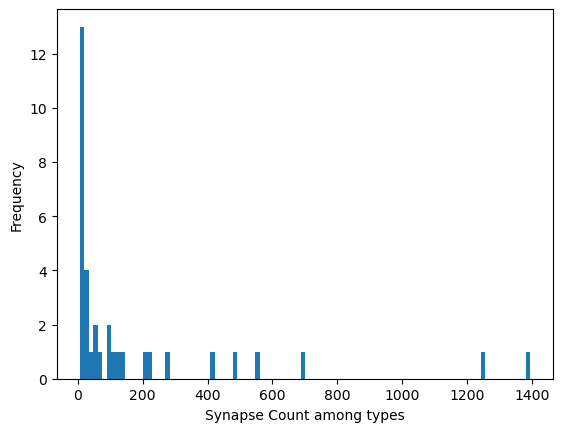

In [23]:
# histogram of syn_count
plt.hist(sexy_type_conns['syn_count'], bins=100)
plt.xlabel('Synapse Count among types')
plt.ylabel('Frequency')

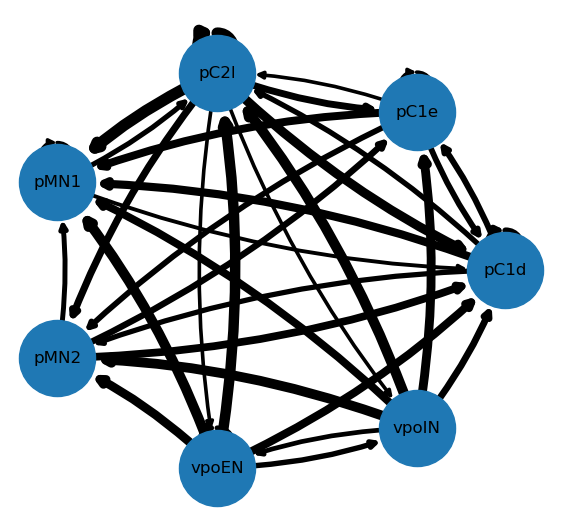

In [24]:
import matplotlib.pyplot as plt
for side in ["left", "bottom", "top", "right"]:
    plt.rcParams[f"axes.spines.{side}"] = False

fig = plt.figure(figsize=(7, 6.5))

# make a networkx graph
G = nx.from_pandas_edgelist(sexy_type_conns, 'pre_type', 'post_type', ['syn_count'], create_using=nx.DiGraph())
edge_labels = nx.get_edge_attributes(G, 'syn_count')

pos = nx.circular_layout(G)
options = {
    #"font_size": 12,
    "node_size": 3000,
    #"node_color": "white",
    #"edgecolors": "black",
    #"linewidths": 5,
    "width": 1 + np.log([G.get_edge_data(u,v)["syn_count"] for u,v in G.edges]),
    "connectionstyle": "arc3,rad=0.09"
}
nx.draw_networkx(G, pos, **options)
#nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

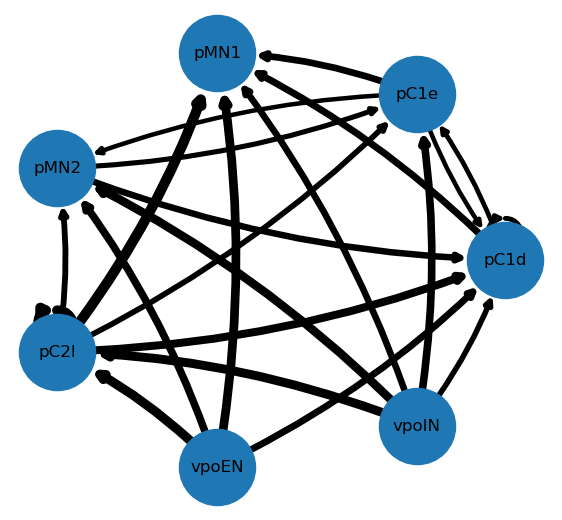

In [25]:
# only the strong connections
strong_sexy_type_conns = sexy_type_conns[sexy_type_conns['syn_count'] >= 20]

import matplotlib.pyplot as plt
for side in ["left", "bottom", "top", "right"]:
    plt.rcParams[f"axes.spines.{side}"] = False

fig = plt.figure(figsize=(7, 6.5))

# make a networkx graph
G = nx.from_pandas_edgelist(strong_sexy_type_conns, 'pre_type', 'post_type', ['syn_count'], create_using=nx.DiGraph())
edge_labels = nx.get_edge_attributes(G, 'syn_count')

pos = nx.circular_layout(G)
options = {
    #"font_size": 12,
    "node_size": 3000,
    #"node_color": "white",
    #"edgecolors": "black",
    #"linewidths": 5,
    "width": 0.1 + np.log([G.get_edge_data(u,v)["syn_count"] for u,v in G.edges]),
    "connectionstyle": "arc3,rad=0.09"
}
nx.draw_networkx(G, pos, **options)
#nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

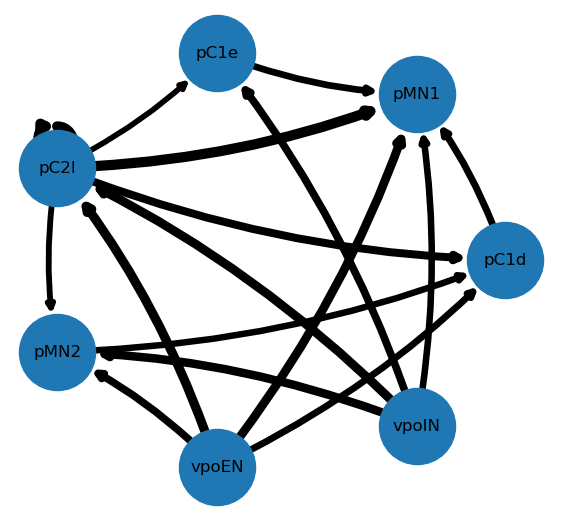

In [26]:
# only the strong connections
strong_sexy_type_conns = sexy_type_conns[sexy_type_conns['syn_count'] >= 50]

import matplotlib.pyplot as plt
for side in ["left", "bottom", "top", "right"]:
    plt.rcParams[f"axes.spines.{side}"] = False

fig = plt.figure(figsize=(7, 6.5))

# make a networkx graph
G = nx.from_pandas_edgelist(strong_sexy_type_conns, 'pre_type', 'post_type', ['syn_count'], create_using=nx.DiGraph())
edge_labels = nx.get_edge_attributes(G, 'syn_count')

pos = nx.circular_layout(G)
options = {
    #"font_size": 12,
    "node_size": 3000,
    #"node_color": "white",
    #"edgecolors": "black",
    #"linewidths": 5,
    "width": 0.1 + np.log([G.get_edge_data(u,v)["syn_count"] for u,v in G.edges]),
    "connectionstyle": "arc3,rad=0.09"
}
nx.draw_networkx(G, pos, **options)
#nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

{('pC1d', 'pC1d'): Text(1.0, 8.514948963609798e-09, '32'),
 ('pC1d', 'pC1e'): Text(0.8117449049695933, 0.39091574665765266, '27'),
 ('pC1d', 'pMN1'): Text(0.38873954709122704, 0.48746394302286616, '131'),
 ('pC1e', 'pC1d'): Text(0.8117449049695933, 0.39091574665765266, '23'),
 ('pC1e', 'pMN1'): Text(0.2004844520608203, 0.8783796811655699, '113'),
 ('pC1e', 'pMN2'): Text(-0.13873948748658427, 0.6078576472705552, '23'),
 ('pMN2', 'pC1d'): Text(0.04951560754382245, 0.21694190912785158, '96'),
 ('pMN2', 'pC1e'): Text(-0.13873948748658427, 0.6078576472705552, '36'),
 ('pC2l', 'pC1d'): Text(0.04951560754382245, -0.21694186229563228, '283'),
 ('pC2l', 'pC1e'): Text(-0.13873948748658427, 0.1739738758470714, '53'),
 ('pC2l', 'pC2l'): Text(-0.9009687849123551, -0.43388373310621353, '1247'),
 ('pC2l', 'pMN1'): Text(-0.5617448453649505, 0.2705220722122849, '1396'),
 ('pC2l', 'pMN2'): Text(-0.9009687849123551, 3.8317270328880326e-08, '61'),
 ('vpoEN', 'pC1d'): Text(0.38873951728890566, -0.487463925

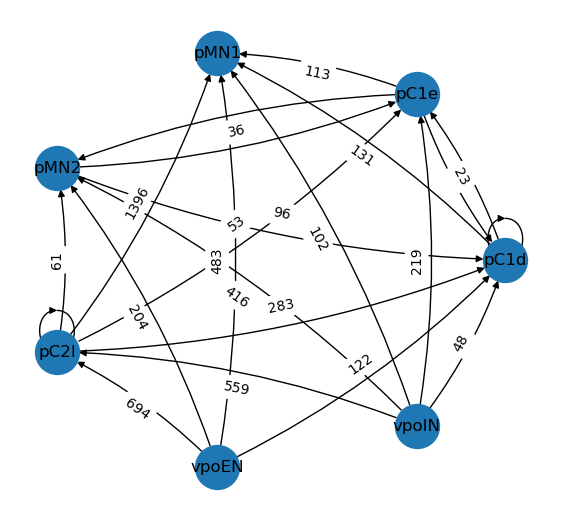

In [27]:
# only the strong connections
strong_sexy_type_conns = sexy_type_conns[sexy_type_conns['syn_count'] >= 20]

import matplotlib.pyplot as plt
for side in ["left", "bottom", "top", "right"]:
    plt.rcParams[f"axes.spines.{side}"] = False

fig = plt.figure(figsize=(7, 6.5))

# make a networkx graph
G = nx.from_pandas_edgelist(strong_sexy_type_conns, 'pre_type', 'post_type', ['syn_count'], create_using=nx.DiGraph())
edge_labels = nx.get_edge_attributes(G, 'syn_count')

pos = nx.circular_layout(G)
options = {
    #"font_size": 12,
    "node_size": 1000,
    #"node_color": "white",
    #"edgecolors": "black",
    #"linewidths": 5,
    #"width": 0.1 + np.log([G.get_edge_data(u,v)["syn_count"] for u,v in G.edges]),
    "connectionstyle": "arc3,rad=0.09"
}
nx.draw_networkx(G, pos, **options)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

{('pC1d', 'pC1d'): Text(0.14029888666959017, 0.3210704061564835, '32'),
 ('pC1d', 'pC1e'): Text(0.43137582065060875, 0.13347579523698308, '27'),
 ('pC1d', 'pC2l'): Text(0.03483262232746476, 0.014430001268384812, '17'),
 ('pC1d', 'pMN1'): Text(-0.4298505566652049, -0.15672566571547653, '131'),
 ('pC1d', 'pMN2'): Text(0.22034492059102007, 0.5886583824630306, '16'),
 ('pC1e', 'pC1d'): Text(0.43137582065060875, 0.13347579523698308, '23'),
 ('pC1e', 'pC1e'): Text(0.7224527546316274, -0.05411881568251736, '5'),
 ('pC1e', 'pC2l'): Text(0.3259095563084834, -0.17316460965111563, '5'),
 ('pC1e', 'pMN1'): Text(-0.1387736226841863, -0.344320276634977, '113'),
 ('pC1e', 'pMN2'): Text(0.5114218545720387, 0.4010637715435301, '23'),
 ('pC2l', 'pC1d'): Text(0.03483262232746476, 0.014430001268384812, '283'),
 ('pC2l', 'pC1e'): Text(0.3259095563084834, -0.17316460965111563, '53'),
 ('pC2l', 'pC2l'): Text(-0.07063364201466066, -0.2922104036197139, '1247'),
 ('pC2l', 'pMN1'): Text(-0.5353168210073304, -0.4

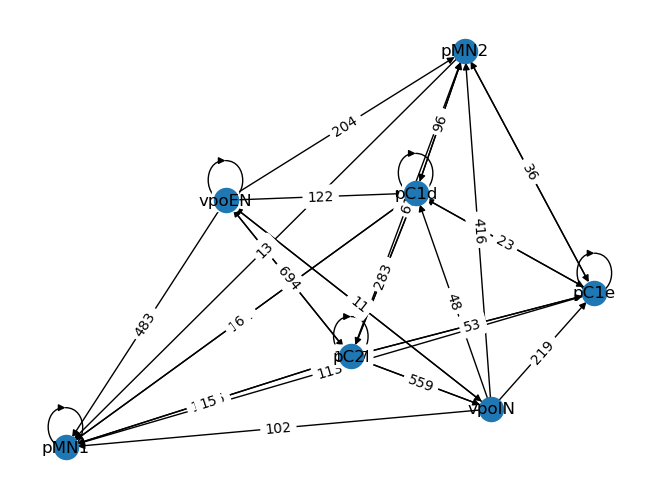

In [28]:
# make a networkx graph
G = nx.from_pandas_edgelist(sexy_type_conns, 'pre_type', 'post_type', ['syn_count'], create_using=nx.DiGraph())
pos = nx.spring_layout(G, seed=42)  # positions for all nodes

# draw the nodes and edges
nx.draw(G, pos, with_labels=True) #, node_size=3000, node_color="lightblue", font_size=10, font_weight="bold", arrowsize=20)
edge_labels = nx.get_edge_attributes(G, 'syn_count')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

## Overlap in inputs

In [29]:
# inputs to pMN1
pMN1_input_conns = simple_connections[simple_connections['post_root_id'].isin(sexy_types[sexy_types['cell_type']=='pMN1']['root_id'].tolist())]
pMN1_inputs = pMN1_input_conns['pre_root_id'].tolist()

In [30]:
# inputs to pMN2
pMN2_input_conns = simple_connections[simple_connections['post_root_id'].isin(sexy_types[sexy_types['cell_type']=='pMN2']['root_id'].tolist())]
pMN2_inputs = pMN2_input_conns['pre_root_id'].tolist()

In [31]:
# inputs to vpoENs
vpoEN_input_conns = simple_connections[simple_connections['post_root_id'].isin(sexy_types[sexy_types['cell_type'] == 'vpoEN']['root_id'].tolist())]
vpoEN_inputs = vpoEN_input_conns['pre_root_id'].tolist()

In [32]:
# inputs to vpoINs
vpoIN_input_conns = simple_connections[simple_connections['post_root_id'].isin(sexy_types[sexy_types['cell_type']=='vpoIN']['root_id'].tolist())]
vpoIN_inputs = vpoIN_input_conns['pre_root_id'].tolist()

In [33]:
#inputs to pC2l
pC2l_input_conns = simple_connections[simple_connections['post_root_id'].isin(sexy_types[sexy_types['cell_type']=='pC2l']['root_id'].tolist())]
pC2l_inputs = pC2l_input_conns['pre_root_id'].tolist()

In [34]:
# inputs to pC1d
pC1d_input_conns = simple_connections[simple_connections['post_root_id'].isin(sexy_types[sexy_types['cell_type']=='pC1d']['root_id'].tolist())]
pC1d_inputs = pC1d_input_conns['pre_root_id'].tolist()

In [35]:
# inputs to pC1e
pC1e_input_conns = simple_connections[simple_connections['post_root_id'].isin(sexy_types[sexy_types['cell_type']=='pC1e']['root_id'].tolist())]
pC1e_inputs = pC1e_input_conns['pre_root_id'].tolist()

In [36]:
# sets of inputs for finding overlaps
pMN1_set = set(pMN1_inputs)
pMN2_set = set(pMN2_inputs)
vpoEN_set = set(vpoEN_inputs)
vpoIN_set = set(vpoIN_inputs)
pC2l_set = set(pC2l_inputs)
pC1d_set =set(pC1d_inputs)
pC1e_set =set(pC1e_inputs)

all_set = pMN1_set.union(pMN2_set).union(vpoEN_set).union(vpoIN_set).union(pC2l_set).union(pC1d_set).union(pC1e_set)

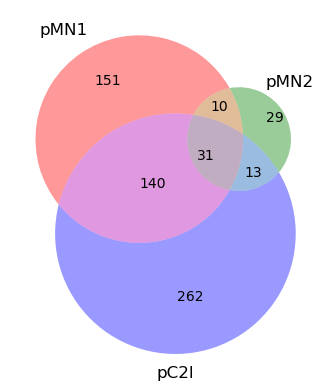

In [37]:
# figure of overlap of inputs to SLP410_R, oviDNb_R, oviDNa_R
from matplotlib_venn import venn3
venn3((pMN1_set, pMN2_set, pC2l_set), ('pMN1', 'pMN2','pC2l'))
plt.show()

In [38]:
# jaccard similarity
def jaccard_similarity(set1, set2):
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union != 0 else 0

In [39]:
jaccard_similarity(pMN1_set, pMN2_set)

0.10962566844919786

In [40]:
jaccard_similarity(pMN1_set, pC2l_set)

0.28171334431630973

In [43]:
jaccard_similarity(vpoEN_set, pMN2_set)

0.033210332103321034

In [44]:
jaccard_similarity(pC1d_set, pMN2_set)

0.12698412698412698

In [45]:
jaccard_similarity(pC1e_set, pMN2_set)

0.10344827586206896

In [46]:
jaccard_similarity(pC1d_set, pC1e_set)

0.24897959183673468

In [47]:
jaccard_similarity(pC1d_set, pC2l_set)

0.14182344428364688

### Overlap in just auditory inputs
It appears that most of the overlapping inputs to pMN1 and pMN2 are auditory neurons. 

In [48]:
len(unique_auditory_ids)

21942

In [49]:
# pMN1 inputs that are also in unique_auditory_ids
len(pMN1_set), len(set(pMN1_inputs).intersection(set(unique_auditory_ids)))

(332, 322)

In [50]:
# pMN2 inputs that are also in unique_auditory_ids
len(pMN2_set), len(set(pMN2_inputs).intersection(set(unique_auditory_ids)))

(83, 60)

In [53]:
# sets of inputs for finding overlaps
pMN1_aud_set = set(pMN1_inputs).intersection(set(unique_auditory_ids))
pMN2_aud_set = set(pMN2_inputs).intersection(set(unique_auditory_ids))
vpoEN_aud_set = set(vpoEN_inputs).intersection(set(unique_auditory_ids))
vpoIN_aud_set = set(vpoIN_inputs).intersection(set(unique_auditory_ids))
pC2l_aud_set = set(pC2l_inputs).intersection(set(unique_auditory_ids))
pC1d_aud_set = set(pC1d_inputs).intersection(set(unique_auditory_ids))
pC1e_aud_set = set(pC1e_inputs).intersection(set(unique_auditory_ids))

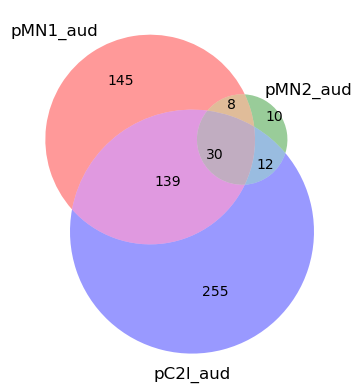

In [54]:
# figure of overlap of inputs to SLP410_R, oviDNb_R, oviDNa_R
from matplotlib_venn import venn3
venn3((pMN1_aud_set, pMN2_aud_set, pC2l_aud_set), ('pMN1_aud', 'pMN2_aud','pC2l_aud'))
plt.show()

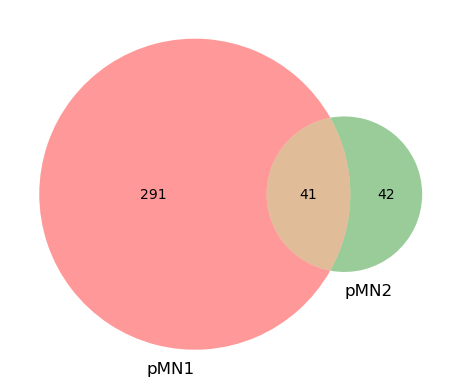

In [55]:
from matplotlib_venn import venn2
venn2((pMN1_set, pMN2_set), ('pMN1', 'pMN2'))
plt.show()

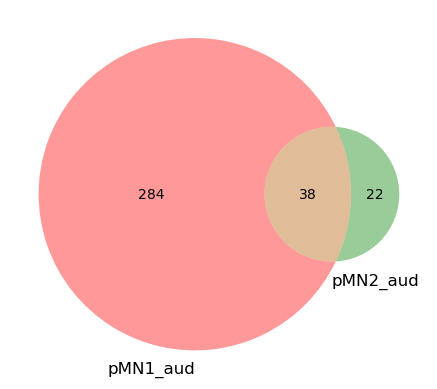

In [56]:
from matplotlib_venn import venn2
venn2((pMN1_aud_set, pMN2_aud_set), ('pMN1_aud', 'pMN2_aud'))
plt.show()

# Modularity
I will do modularity on the inputs to pMN1 and pMN2 separately. They have a fair amount of overlapping inputs but if the modularity results cluster their common inputs quite differently, that would be interesting.

In [57]:
# obtain input connectomes for modularity analysis
pMN1_input_connectome = simple_connections[simple_connections['pre_root_id'].isin(set(pMN1_inputs)) & simple_connections['post_root_id'].isin(set(pMN1_inputs))]
pMN1_input_connectome = pMN1_input_connectome[['pre_root_id', 'post_root_id', 'syn_count']].reset_index(drop=True)

pMN2_input_connectome = simple_connections[simple_connections['pre_root_id'].isin(set(pMN2_inputs)) & simple_connections['post_root_id'].isin(set(pMN2_inputs))]
pMN2_input_connectome = pMN2_input_connectome[['pre_root_id', 'post_root_id', 'syn_count']].reset_index(drop=True)

In [87]:
# export as txt files with space separator
pMN1_input_connectome.to_csv("pMN1_input_connectome.txt", sep=" ", index=False, header=False)
pMN2_input_connectome.to_csv("pMN2_input_connectome.txt", sep=" ", index=False, header=False)

In [58]:
# import the modularity results for pMN1
pMN1_mod = pd.read_csv('gcm_pipeline/results/pMN1_clustering_result.txt', sep=' ', names=['node', 'module'])
pMN1_mod['module'].value_counts()

module
1    107
4     95
2     83
3     44
5      2
Name: count, dtype: int64

In [59]:
# import the modularity results for pMN2
pMN2_mod = pd.read_csv('gcm_pipeline/results/pMN2_clustering_result.txt', sep=' ', names=['node', 'module'])
pMN2_mod['module'].value_counts()

module
1    20
4    18
2    17
3    16
5     2
Name: count, dtype: int64

In [58]:
pMN1_mod[pMN1_mod['module'] == 5], pMN2_mod[pMN2_mod['module'] == 5]

(                   node  module
 130  720575940623166733       5
 259  720575940633462829       5,
                   node  module
 20  720575940619058461       5
 22  720575940619822784       5)

To compare the 2 clusterings, we need to get the nodes that the subconnectomes have in common. Using the analyses we had built before, we have to read the modularity results into a dictionary to pass those into the cluster_similarity function. After reading in the results as dictionaries, we must grab the common sets.

In [60]:
def clustering_dict(filepathname):
    """filepathname: string for the clustering result file path"""
    chi_run = {}

    with open(filepathname, 'r') as f:
        for line in f:
            node, cluster = line.split()
            node = int(node)
            cluster = int(cluster)
            chi_run[node] = cluster

    return chi_run

In [61]:
pMN1_mod_dict = clustering_dict('gcm_pipeline/results/pMN1_clustering_result.txt')
pMN2_mod_dict = clustering_dict('gcm_pipeline/results/pMN2_clustering_result.txt')

In [62]:
# get the intersection of nodes between the two clusterings
common_nodes = set(pMN1_mod_dict.keys()).intersection(set(pMN2_mod_dict.keys()))

# filter the dictionaries to only include common nodes
pMN1_common = {node: pMN1_mod_dict[node] for node in common_nodes}
pMN2_common = {node: pMN2_mod_dict[node] for node in common_nodes}

In [63]:
# count the occurrences of each module in pMN1_common and pMN2_common
pd.Series(list(pMN1_common.values())).value_counts(), pd.Series(list(pMN2_common.values())).value_counts()

(4    25
 1    10
 2     5
 Name: count, dtype: int64,
 1    13
 4    12
 3    10
 2     3
 5     2
 Name: count, dtype: int64)

In [63]:
# show the keys in pMN1_common dict where the module is x
[node for node, module in pMN1_common.items() if module == 1]

[720575940626295326,
 720575940622709287,
 720575940637834301,
 720575940618340057,
 720575940615894877,
 720575940634458719,
 720575940632723938,
 720575940635403230,
 720575940609996773,
 720575940634829168]

In [64]:
# show the keys in pMN2_common dict where the module is x
[node for node, module in pMN2_common.items() if module == 1]

[720575940607262219,
 720575940632385943,
 720575940632192676,
 720575940634396863,
 720575940618364480,
 720575940618248129,
 720575940620356545,
 720575940628542807,
 720575940618340057,
 720575940615635037,
 720575940634458719,
 720575940629373687,
 720575940619415679]

In [64]:
import itertools

def cluster_similarity(cluster_1, cluster_2, mode='both', node_filter=None):
    """
    Calculate the similarity between two clusterings using either the Jaccard index, Rand index, or both.

    Parameters:
    cluster_1 (dict): A dictionary representing the first clustering where keys are nodes and values are cluster labels.
    cluster_2 (dict): A dictionary representing the second clustering where keys are nodes and values are cluster labels.
    mode (str): The similarity measure to use ('jaccard', 'rand', or 'both'). Defaults to 'both'.
    node_filter (set, optional): A set of nodes to include in the comparison. If None, all nodes are included.

    Returns:
    float or tuple: The Jaccard index, Rand index, or both depending on the selected mode.
    
    Raises:
    AssertionError: If the mode is not one of 'jaccard', 'rand', or 'both', or if the clusterings do not have the same nodes.
    """
    # Ensure the mode is one of the valid options
    assert mode in ['jaccard', 'rand', 'both'], "Not a valid mode, please choose 'jaccard', 'rand' or 'both'"
    # Ensure both clusterings have the same set of nodes
    assert set(cluster_1.keys()) == set(cluster_2.keys())
    nodes = set(cluster_1.keys())
    
    # Apply node filter if provided
    if node_filter is not None:
        filter_set = set(node_filter)
        nodes = nodes.intersection(filter_set)
    
    # Initialize counters for pair counts
    f_0_0 = 0  # pair in different clusters in both clusterings
    f_0_1 = 0  # pair in different clusters in cluster_1 and same in cluster_2
    f_1_0 = 0  # pair in same cluster in cluster_1 and different in cluster_2
    f_1_1 = 0  # pair in same clusters in both clusterings

    # Count the number of pairs in each category
    for n1, n2 in itertools.combinations(nodes, 2):
        if cluster_1[n1] == cluster_1[n2] and cluster_2[n1] == cluster_2[n2]:
            f_1_1 += 1
        elif cluster_1[n1] == cluster_1[n2] and cluster_2[n1] != cluster_2[n2]:
            f_1_0 += 1
        elif cluster_1[n1] != cluster_1[n2] and cluster_2[n1] == cluster_2[n2]:
            f_0_1 += 1
        else:
            f_0_0 += 1
    #print(f_0_0 + f_1_0 + f_1_1 + f_0_1)
    # Calculate and return the similarity measure(s)
    if mode == 'jaccard':
        return f_1_1 / (f_1_1 + f_0_1 + f_1_0)
    if mode == 'rand':
        return (f_1_1 + f_0_0) / (f_1_1 + f_1_0 + f_0_1 + f_0_0)
    
    return f_1_1 / (f_1_1 + f_0_1 + f_1_0), (f_1_1 + f_0_0) / (f_1_1 + f_1_0 + f_0_1 + f_0_0)

In [65]:
jaccard_index, rand_score = cluster_similarity(pMN1_common, pMN2_common, mode='both')
jaccard_index, rand_score

(0.26558891454965355, 0.5923076923076923)

These are the common inputs to pMN1 and pMN2. There are 40 neurons in common. They include the pC2l, pC1d, pC1e, vpoEN, and vpoIN.

In [66]:
# merge the two modularity dataframes on 'node' to compare modules
merged_mod = pMN1_mod.merge(pMN2_mod, on='node', suffixes=('_pMN1', '_pMN2'))

#merge the cell types onto the df
merged_mod = merged_mod.merge(types, left_on='node', right_on='root_id').drop(columns=['root_id'])

merged_mod

,node,module_pMN1,module_pMN2,primary_type,additional_type(s)
0,720575940607262219,2,1,CB3483,NaN
1,720575940609996773,1,3,CB3313,AVLP_pr36
2,720575940612139443,4,2,SMP093,NaN
3,720575940612403427,4,4,AVLP008,"vpoIN, aSP8_vpoIN"
4,720575940614752395,4,4,AVLP008,"vpoIN, aSP8_vpoIN"
5,720575940615635037,2,1,CB3313,AVLP_pr36
6,720575940615894877,1,4,CB1385,vpoIN
7,720575940618248129,2,1,AVLP297,NaN
8,720575940618340057,1,1,PVLP093,NaN
9,720575940618364480,4,1,pC1e,NaN


In [67]:
# merge the auditory cell types onto the df
merged_mod.merge(sexy_types[['root_id','cell_type']], left_on='node', right_on='root_id').drop(columns=['root_id'])

,node,module_pMN1,module_pMN2,primary_type,additional_type(s),cell_type
0,720575940612403427,4,4,AVLP008,"vpoIN, aSP8_vpoIN",vpoIN
1,720575940614752395,4,4,AVLP008,"vpoIN, aSP8_vpoIN",vpoIN
2,720575940615894877,1,4,CB1385,vpoIN,vpoIN
3,720575940618364480,4,1,pC1e,NaN,pC1e
4,720575940618475101,4,4,AVLP567,pC2lb,pC2l
5,720575940619415679,4,1,vpoEN,NaN,vpoEN
6,720575940620356545,4,1,pC1d,NaN,pC1d
7,720575940623256202,4,4,AVLP008,"vpoIN, aSP8_vpoIN",vpoIN
8,720575940623725972,4,4,AVLP567,pC2lb,pC2l
9,720575940627718394,4,4,AVLP008,aSP8_vpoIN,vpoIN


# Connectivity data by types

In [68]:
# merges types onto simple connections dataframe
simple_connections_types = simple_connections.merge(types[['root_id', 'primary_type']], left_on='pre_root_id', right_on='root_id').drop(columns=['root_id']).rename(columns={'primary_type': 'pre_type'})
simple_connections_types = simple_connections_types.merge(types[['root_id', 'primary_type']], left_on='post_root_id', right_on='root_id').drop(columns=['root_id']).rename(columns={'primary_type': 'post_type'})
simple_connections_types

,pre_root_id,post_root_id,syn_count,nt_type,pre_type,post_type
0,720575940596125868,720575940605825666,6,ACH,T5c,LPLC2
1,720575940596125868,720575940608552405,6,ACH,T5c,Tlp14
2,720575940596125868,720575940609975854,5,ACH,T5c,LPC2
3,720575940596125868,720575940613059993,9,ACH,T5c,LPC2
4,720575940596125868,720575940613599129,6,ACH,T5c,Y3
...,...,...,...,...,...,...
3675146,720575940661339777,720575940622727152,37,ACH,R1-6,Lai
3675147,720575940661339777,720575940625109995,5,ACH,R1-6,T1
3675148,720575940661339777,720575940627311491,40,ACH,R1-6,L1
3675149,720575940661339777,720575940628084873,19,ACH,R1-6,L3


In [69]:
# groupby pre_type and post_type and sum syn_count
type_connections = simple_connections_types[['pre_type', 'post_type', 'syn_count']].groupby(['pre_type', 'post_type']).sum().reset_index()
type_connections

,pre_type,post_type,syn_count
0,4A0,4A10,5
1,4A0,4A21,8
2,4A0,4D3,7
3,4A0,4I1,11
4,4A0,4I2,16
...,...,...,...
492389,vpoEN,PVLP027,6
492390,vpoEN,SMP028,51
492391,vpoEN,WED069,30
492392,vpoEN,pC1d,122


In [70]:
type_connections[type_connections['pre_type'] == 'vpoEN'].sort_values('syn_count', ascending=False)

,pre_type,post_type,syn_count
492338,vpoEN,AVLP083,432
492354,vpoEN,AVLP569,400
492381,vpoEN,DNp55,397
492377,vpoEN,DNp13,324
492357,vpoEN,CB1090,298
...,...,...,...
492342,vpoEN,AVLP290a,5
492340,vpoEN,AVLP202,5
492368,vpoEN,CB3269,5
492335,vpoEN,AVLP020,5


In [71]:
vpoIN_output_conns = type_connections[type_connections['pre_type'].isin(sexy_types[sexy_types['cell_type']=='vpoIN']['primary_type'].tolist())].sort_values('syn_count', ascending=False)
vpoIN_output_conns

,pre_type,post_type,syn_count
39206,AVLP008,AVLP567,394
39223,AVLP008,DNp37,337
39236,AVLP008,pC1e,206
306550,LHAV4c2,AVLP316,162
39218,AVLP008,CL265,158
...,...,...,...
39231,AVLP008,PVLP137,5
307003,LHAV4j1,LHAV3e3a,5
39228,AVLP008,DNpe052,5
39224,AVLP008,DNp55,5


In [72]:
# group by post_type and sum syn_count
vpoIN_output_conns_grouped = vpoIN_output_conns[['post_type', 'syn_count']].groupby('post_type').sum().reset_index().sort_values('syn_count', ascending=False)
vpoIN_output_conns_grouped

,post_type,syn_count
153,DNp37,466
34,AVLP567,455
241,pC1e,225
7,AVLP029,186
23,AVLP316,162
...,...,...
201,PVLP007,5
65,CB1491,5
205,PVLP123b,5
206,PVLP137,5


Who are the top inputs to pMN1 and pMN2 and how do they compare to each other? I'm going to first make a df of types but with a new column that has primary_types and replaces those values with sexy_types wherever possible.

In [73]:
# make a copy of types dataframe
complete_types = types.copy()

# merge sexy_types onto complete_types
complete_types = complete_types.merge(sexy_types[['root_id', 'cell_type']], on='root_id', how='left')
complete_types

,root_id,primary_type,additional_type(s),cell_type
0,720575940596125868,T5c,NaN,NaN
1,720575940597856265,Tm16,NaN,NaN
2,720575940597944841,Tm7,CB3851,NaN
3,720575940598267657,TmY15,NaN,NaN
4,720575940599333574,Tm1,NaN,NaN
...,...,...,...,...
137672,720575940661335681,CB0180,NaN,NaN
137673,720575940661336193,TmY3,NaN,NaN
137674,720575940661337217,KCab-p,NaN,NaN
137675,720575940661338497,CB0904,NaN,NaN


In [74]:
# add a new column 'consolidated_type' to complete_types that uses sexy_types where possible and primary_type otherwise
complete_types['consolidated_type'] = np.where(complete_types['root_id'].isin(sexy_types['root_id'].tolist()), complete_types['cell_type'], complete_types['primary_type'])
complete_types

,root_id,primary_type,additional_type(s),cell_type,consolidated_type
0,720575940596125868,T5c,NaN,NaN,T5c
1,720575940597856265,Tm16,NaN,NaN,Tm16
2,720575940597944841,Tm7,CB3851,NaN,Tm7
3,720575940598267657,TmY15,NaN,NaN,TmY15
4,720575940599333574,Tm1,NaN,NaN,Tm1
...,...,...,...,...,...
137672,720575940661335681,CB0180,NaN,NaN,CB0180
137673,720575940661336193,TmY3,NaN,NaN,TmY3
137674,720575940661337217,KCab-p,NaN,NaN,KCab-p
137675,720575940661338497,CB0904,NaN,NaN,CB0904


In [75]:
complete_types[complete_types['consolidated_type']=='pMN1']

,root_id,primary_type,additional_type(s),cell_type,consolidated_type
38947,720575940619486891,DNp13,pMN1/DNp13,pMN1,pMN1
66096,720575940624463242,CB0666,"hb-953013850, pMN1",pMN1,pMN1
70282,720575940625295339,DNp13,pMN1/DNp13,pMN1,pMN1
132092,720575940644300323,CB0666,"hb-953013850, pMN1",pMN1,pMN1


In [76]:
# top inputs to pMN1 by consolidated type
_pMN1_input_types = pMN1_input_conns[['pre_root_id','syn_count']].merge(complete_types[['root_id', 'consolidated_type']], left_on='pre_root_id', right_on='root_id').drop(columns=['root_id']).rename(columns={'consolidated_type': 'pre_type'})
pMN1_input_types = _pMN1_input_types[['pre_type','syn_count']].groupby('pre_type').sum().reset_index().sort_values('syn_count', ascending=False)
pMN1_input_types.head(10)

,pre_type,syn_count
137,pC2l,1396
140,vpoEN,483
22,AVLP370b,395
1,AN_AVLP_GNG_19,377
20,AVLP340,252
76,CL037,184
115,PVLP093,181
40,CB1090,155
103,LC31b,152
49,CB1783,146


In [77]:
# top inputs to pMN2 by consolidated type
_pMN2_input_types = pMN2_input_conns[['pre_root_id','syn_count']].merge(complete_types[['root_id', 'consolidated_type']], left_on='pre_root_id', right_on='root_id').drop(columns=['root_id']).rename(columns={'consolidated_type': 'pre_type'})
pMN2_input_types = _pMN2_input_types[['pre_type','syn_count']].groupby('pre_type').sum().reset_index().sort_values('syn_count', ascending=False)
pMN2_input_types.head(10)

,pre_type,syn_count
31,vpoIN,416
24,pC1a,410
30,vpoEN,204
26,pC1c,127
21,SMP157,126
3,AVLP297,83
7,CB1865,70
23,aSP8,62
29,pC2l,61
16,LHAV4c2,45


In [78]:
pMN1_input_types['syn_count'].sum(), pMN2_input_types['syn_count'].sum()

(7121, 1971)

In [80]:
pMN1_input_types[pMN1_input_types['pre_type'].str.contains('pC1|SAG')]

,pre_type,syn_count
135,pC1d,131
136,pC1e,113
134,pC1c,58


In [81]:
pMN1_input_types[pMN1_input_types['pre_type'].str.contains('pMN')]

,pre_type,syn_count
139,pMN2,13
138,pMN1,5


In [82]:
pMN2_input_types[pMN2_input_types['pre_type'].str.contains('pMN')]

,pre_type,syn_count


In [83]:
pMN2_input_types[pMN2_input_types['pre_type'].str.contains('pC1|SAG')]

,pre_type,syn_count
24,pC1a,410
26,pC1c,127
28,pC1e,23
25,pC1b,19
27,pC1d,16


### What is downstream of the pMN1 and pMN2?

In [79]:
# outputs from pMN1
pMN1_output_conns = simple_connections[simple_connections['pre_root_id'].isin(sexy_types[sexy_types['cell_type']=='pMN1']['root_id'].tolist())]
pMN1_outputs = pMN1_output_conns['post_root_id'].tolist()

In [80]:
# outputs from pMN2
pMN2_output_conns = simple_connections[simple_connections['pre_root_id'].isin(sexy_types[sexy_types['cell_type']=='pMN2']['root_id'].tolist())]
pMN2_outputs = pMN2_output_conns['post_root_id'].tolist()

In [81]:
# top outputs from pMN1 by consolidated type
_pMN1_output_types = pMN1_output_conns[['post_root_id','syn_count']].merge(complete_types[['root_id', 'consolidated_type']], left_on='post_root_id', right_on='root_id').drop(columns=['root_id']).rename(columns={'consolidated_type': 'post_type'})
pMN1_output_types = _pMN1_output_types[['post_type','syn_count']].groupby('post_type').sum().reset_index().sort_values('syn_count', ascending=False)
pMN1_output_types.head(10)

,post_type,syn_count
9,CB0174,186
31,DNpe020,158
11,CB0200,103
36,PS164,88
7,CB0069,75
8,CB0076,67
26,DNge079,51
20,DNg105,49
14,CB0609,45
32,DNpe050,31


In [82]:
# top outputs from pMN2 by consolidated type
_pMN2_output_types = pMN2_output_conns[['post_root_id','syn_count']].merge(complete_types[['root_id', 'consolidated_type']], left_on='post_root_id', right_on='root_id').drop(columns=['root_id']).rename(columns={'consolidated_type': 'post_type'})
pMN2_output_types = _pMN2_output_types[['post_type','syn_count']].groupby('post_type').sum().reset_index().sort_values('syn_count', ascending=False)
pMN2_output_types.head(10)

,post_type,syn_count
12,pC1d,96
9,pC1a,63
3,CB2695,55
4,CL037,44
11,pC1c,40
13,pC1e,36
2,CB0584,29
0,CB0009,28
5,DNg19,26
10,pC1b,13


Sidebar: something interesting is going on here. vpoIN is the strongest input type to vpoDN/pMN2 and pC1a is next in line before vpoEN. Could it be that pC1a has a strong reciprocal relationship with vpoIN, and is therefore the true triad member? Looks like they don't even touch each other, so I guess not. 

In [83]:
# merges complete_types onto simple connections dataframe
simple_connections_types_cs = simple_connections.merge(complete_types[['root_id', 'consolidated_type']], left_on='pre_root_id', right_on='root_id').drop(columns=['root_id']).rename(columns={'consolidated_type': 'pre_type'})
simple_connections_types_cs = simple_connections_types_cs.merge(complete_types[['root_id', 'consolidated_type']], left_on='post_root_id', right_on='root_id').drop(columns=['root_id']).rename(columns={'consolidated_type': 'post_type'})
simple_connections_types_cs

,pre_root_id,post_root_id,syn_count,nt_type,pre_type,post_type
0,720575940596125868,720575940605825666,6,ACH,T5c,LPLC2
1,720575940596125868,720575940608552405,6,ACH,T5c,Tlp14
2,720575940596125868,720575940609975854,5,ACH,T5c,LPC2
3,720575940596125868,720575940613059993,9,ACH,T5c,LPC2
4,720575940596125868,720575940613599129,6,ACH,T5c,Y3
...,...,...,...,...,...,...
3675146,720575940661339777,720575940622727152,37,ACH,R1-6,Lai
3675147,720575940661339777,720575940625109995,5,ACH,R1-6,T1
3675148,720575940661339777,720575940627311491,40,ACH,R1-6,L1
3675149,720575940661339777,720575940628084873,19,ACH,R1-6,L3


In [84]:
# groupby pre_type and post_type and sum syn_count
type_connections_cs = simple_connections_types_cs[['pre_type', 'post_type', 'syn_count']].groupby(['pre_type', 'post_type']).sum().reset_index()
type_connections_cs

,pre_type,post_type,syn_count
0,4A0,4A10,5
1,4A0,4A21,8
2,4A0,4D3,7
3,4A0,4I1,11
4,4A0,4I2,16
...,...,...,...
492256,vpoIN,pC1e,219
492257,vpoIN,pC2l,559
492258,vpoIN,pMN1,102
492259,vpoIN,pMN2,416


In [90]:
type_connections_cs[(type_connections_cs['pre_type']=='vpoIN') & (type_connections_cs['post_type']=='pC1a')]

,pre_type,post_type,syn_count


In [91]:
type_connections_cs[(type_connections_cs['pre_type']=='pC1a') & (type_connections_cs['post_type']=='vpoIN')]

,pre_type,post_type,syn_count


In [92]:
type_connections_cs[(type_connections_cs['pre_type'].str.contains('vpoIN|pC1a', case=False, na=False)) & (type_connections_cs['post_type'].str.contains('vpoIN|pC1a', case=False, na=False))]

,pre_type,post_type,syn_count
489953,pC1a,pC1a,76


## How many of the pMN inputs are also outputs of either pMN?
About 3.3% of inputs to pMN1 are also outputs of pMN2. But by input weight, about 7% of input weights to pMN1 are from outputs of pMN2. 

In [90]:
set(pMN1_inputs).intersection(set(pMN2_outputs))

{720575940605302974,
 720575940613113325,
 720575940618364480,
 720575940618984475,
 720575940620203502,
 720575940620356545,
 720575940624463242,
 720575940626656010,
 720575940629430978,
 720575940634866586,
 720575940646518382}

In [95]:
len(set(pMN1_inputs).intersection(set(pMN2_outputs)))

11

In [94]:
len(set(pMN1_inputs).intersection(set(pMN2_outputs+pMN1_outputs)))

19

In [97]:
len(set(pMN1_inputs).intersection(set(pMN2_outputs)))/len(set(pMN1_inputs))

0.03313253012048193

In [99]:
pMN1_input_conns

,pre_root_id,post_root_id,syn_count,nt_type
966,720575940602120928,720575940619486891,17,ACH
1364,720575940602483424,720575940619486891,17,ACH
13393,720575940604088288,720575940625295339,21,GLUT
19336,720575940604445868,720575940619486891,10,ACH
19362,720575940604445868,720575940644300323,10,ACH
...,...,...,...,...
3639586,720575940646518382,720575940644300323,63,ACH
3675900,720575940649591673,720575940619486891,6,GABA
3685725,720575940650929273,720575940644300323,7,DA
3693294,720575940652283126,720575940624463242,5,ACH


In [104]:
out2_in1 = set(pMN1_inputs).intersection(set(pMN2_outputs))

# sum of all input weight to pMN1
total_in_syncount_pMN1 = pMN1_input_conns['syn_count'].sum()

# sum of input weight to pMN1 from neurons that also output from pMN2
out2_in1_syncount_pMN1 = pMN1_input_conns[pMN1_input_conns['pre_root_id'].isin(out2_in1)]['syn_count'].sum()

# the ratio
out2_in1_syncount_pMN1 / total_in_syncount_pMN1

0.0711897464474784

There is less overlap between the inputs to pMN2 and the outputs from pMN1.

In [93]:
set(pMN2_inputs).intersection(set(pMN1_outputs))

{720575940620356545}

In [96]:
len(set(pMN2_inputs).intersection(set(pMN2_outputs+pMN1_outputs)))

10

In [98]:
len(set(pMN2_inputs).intersection(set(pMN1_outputs)))/len(set(pMN2_inputs))

0.012048192771084338

# JO connectivity
As a group, the JO-A connect the most to the WV-WV-3 and WV-WV-1. The strongest input by cell type to WV-WV-3 are the JO-A. Christa's hierarchical analysis indicates that there are many subclusters of JO-A and JO-B. I wonder what the distribution of JO-A to WV-WV-3 connections are like. Just looking at a few handpicked examples, it doesn't look like most JO-A choose an individual WV-WV-3 as their strongest output. 

In [93]:
type_connections_cs[type_connections_cs['pre_type']=='JO-A'].sort_values('syn_count', ascending=False).head(20)

,pre_type,post_type,syn_count
279666,JO-A,WV-WV-3,3540
279664,JO-A,WV-WV-1,2990
279547,JO-A,CB1817a,2587
279548,JO-A,CB1817b,2166
279609,JO-A,DNg24,1832
279510,JO-A,CB0307,1568
279511,JO-A,CB0443,1550
279610,JO-A,DNg29,1518
279516,JO-A,CB0591,1470
279619,JO-A,DNge130,1446


In [94]:
type_connections_cs[type_connections_cs['pre_type']=='JO-B'].sort_values('syn_count', ascending=False).head(20)

,pre_type,post_type,syn_count
279715,JO-B,CB1078,4156
279765,JO-B,CB2556,2588
279735,JO-B,CB1542,1975
279714,JO-B,CB1076,1430
279798,JO-B,CB3719,1408
279713,JO-B,CB1075,1178
279709,JO-B,CB1038,1041
279729,JO-B,CB1427,991
279755,JO-B,CB2162,944
279768,JO-B,CB2664,934


In [95]:
type_connections_cs[type_connections_cs['post_type']=='WV-WV-3'].sort_values('syn_count', ascending=False).head(20)

,pre_type,post_type,syn_count
279666,JO-A,WV-WV-3,3540
255749,DNg40,WV-WV-3,1155
474872,WV-WV-3,WV-WV-3,957
219955,CB3719,WV-WV-3,868
162237,CB1948,WV-WV-3,854
92934,CB0261,WV-WV-3,688
279876,JO-B,WV-WV-3,601
139998,CB1280,WV-WV-3,552
254949,DNg24,WV-WV-3,515
199010,CB3105,WV-WV-3,459


In [96]:
type_connections_cs[type_connections_cs['post_type']=='WV-WV-1'].sort_values('syn_count', ascending=False).head(20)

,pre_type,post_type,syn_count
132409,CB1078,WV-WV-1,4247
279664,JO-A,WV-WV-1,2990
148833,CB1542,WV-WV-1,1131
148620,CB1538,WV-WV-1,647
254947,DNg24,WV-WV-1,600
202617,CB3245,WV-WV-1,420
110602,CB0591,WV-WV-1,418
137175,CB1206,WV-WV-1,401
403547,SAD021_a,WV-WV-1,365
46325,AVLP083,WV-WV-1,347


In [97]:
simple_connections_types_cs[simple_connections_types_cs['pre_type']=='JO-A']

,pre_root_id,post_root_id,syn_count,nt_type,pre_type,post_type
88967,720575940606612937,720575940604201830,11,ACH,JO-A,WV-WV-3
88968,720575940606612937,720575940605214636,39,ACH,JO-A,WV-WV-3
88969,720575940606612937,720575940610091955,12,ACH,JO-A,DNge113
88970,720575940606612937,720575940611335859,6,ACH,JO-A,CB1969
88971,720575940606612937,720575940612193682,34,ACH,JO-A,CB3105
...,...,...,...,...,...,...
3519115,720575940643903904,720575940638214461,43,ACH,JO-A,CB1817b
3519116,720575940643903904,720575940639118926,8,ACH,JO-A,DNg24
3519117,720575940643903904,720575940639421299,13,ACH,JO-A,CB2144
3519118,720575940643903904,720575940642474637,12,ACH,JO-A,CB2576


In [98]:
complete_types[complete_types['consolidated_type']=='JO-A']['root_id'].values[0]

720575940606612937

In [99]:
simple_connections_types_cs[simple_connections_types_cs['pre_root_id']==complete_types[complete_types['consolidated_type']=='JO-A']['root_id'].values[0]].sort_values('syn_count', ascending=False)

,pre_root_id,post_root_id,syn_count,nt_type,pre_type,post_type
88979,720575940606612937,720575940622579967,71,ACH,JO-A,DNg29
88996,720575940606612937,720575940646521198,43,ACH,JO-A,CB0591
88968,720575940606612937,720575940605214636,39,ACH,JO-A,WV-WV-3
88981,720575940606612937,720575940624750480,38,ACH,JO-A,DNg24
88990,720575940606612937,720575940635330204,37,ACH,JO-A,WV-WV-1
88971,720575940606612937,720575940612193682,34,ACH,JO-A,CB3105
88977,720575940606612937,720575940621586473,29,ACH,JO-A,DNg09
88973,720575940606612937,720575940617286517,27,ACH,JO-A,AN_multi_33
88974,720575940606612937,720575940619891591,24,ACH,JO-A,AN_multi_33
88991,720575940606612937,720575940635723887,21,ACH,JO-A,CB3105


In [100]:
simple_connections_types_cs[simple_connections_types_cs['pre_root_id']==complete_types[complete_types['consolidated_type']=='JO-A']['root_id'].values[4]].sort_values('syn_count', ascending=False)

,pre_root_id,post_root_id,syn_count,nt_type,pre_type,post_type
155159,720575940608457483,720575940629133071,104,ACH,JO-A,CB1817a
155164,720575940608457483,720575940632649697,68,ACH,JO-A,CB1817b
155140,720575940608457483,720575940619378123,59,ACH,JO-A,CB0255
155165,720575940608457483,720575940632945177,59,ACH,JO-A,WV-WV-3
155170,720575940608457483,720575940638214461,57,ACH,JO-A,CB1817b
155145,720575940608457483,720575940622123981,47,ACH,JO-A,WV-WV-1
155151,720575940608457483,720575940625223944,46,ACH,JO-A,CB0443
155157,720575940608457483,720575940627490459,42,ACH,JO-A,DNge130
155172,720575940608457483,720575940643347616,38,ACH,JO-A,DNp55
155169,720575940608457483,720575940638024832,36,ACH,JO-A,SAD016


None of the WV-WV are presynaptic to either pMN.

In [101]:
type_connections_cs[(type_connections_cs['pre_type'].str.contains('WV-WV')) & (type_connections_cs['post_type'].str.contains('pMN'))]

,pre_type,post_type,syn_count


The JO-A connect directly to the vpoEN but not to the pMNs. So JO-A are as few as 2-hops away from pMNs which both get lots of input from vpoEN. 

In [103]:
type_connections_cs[(type_connections_cs['pre_type'].str.contains('JO')) & (type_connections_cs['post_type'].isin(sexy_types['cell_type'].tolist()))]

,pre_type,post_type,syn_count
279671,JO-A,vpoEN,9


In [104]:
type_connections_cs[(type_connections_cs['pre_type'].str.contains('vpoEN')) & (type_connections_cs['post_type'].str.contains('pMN'))]

,pre_type,post_type,syn_count
492094,vpoEN,pMN1,483
492095,vpoEN,pMN2,204
